# Confusion Matrices analysis notebooks




## Prompts:

1. judge: 
```python
    """"
        [System] 
        Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to a question displayed below. Your evaluation should consider factors such as relevance and accuracy. Begin your evaluation by providing a short explanation. Be as objective as possible. After providing your explanation, please classify the response as 1 for GOOD and 0 for BAD by strictly following this format: "[[classification]]", for example: "Classification: [[1]]".  
        [Question] 
        {question}  
        [The Start of Assistant’s Answer] 
        {response}
        [The End of Assistant’s Answer]
    """

```

2. alt1:
```python
    """"
    [System] 
    Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to a question displayed below. Begin your evaluation by providing a short explanation. Be as objective as possible. After providing your explanation, please classify the response as 1 for RESPONDS QUESTION and 0 for NOT RESPONDES QUESTION by strictly following this format: "[[classification]]", for example: "Classification: [[1]]".  
    [Question] 
    {question}  
    [The Start of Assistant’s Answer] 
    {response}
    [The End of Assistant’s Answer]
    """

```
3. alt2:
```python
    """
    [System]
    You are an expert evaluator focusing on "Helpfulness-First" metrics. Your goal is to identify if the AI response successfully helps the user, even if the phrasing isn't perfect.

    ### Scoring Guidelines:
    - Classify as GOOD (1): The answer is factually correct, addresses the user's intent, and is safe. Minor stylistic issues or slight wordiness should NOT result in a 0.
    - Classify as BAD (0): The answer is factually wrong, ignores the user's constraints, or is completely unhelpful.

    [Question]
    {question}

    [Assistant's Answer]
    {response}

    ### Task:
    1. Determine if the core question was answered correctly.
    2. Ignore minor formatting or conversational filler.
    3. Provide your reasoning briefly.
    4. Format the final output as: Classification: [[1]] or Classification: [[0]]
    
    Analysis and Classification:
    """

```

## Resultados Prévios


The acheived mean ROUC-AUC score and std achieved where:
| Model                     | Type        | Mean | Std  |
| ------------------------- | ----------- | ---- | ---- |
| Logistic Regression       | Groundturth | 0.84 | 0.13 |
| Logistic Regression       | Judge       | 0.57 | 0.07 |
| LR - Balanced Weights     | Groundturth | 0.83 | 0.13 |
| LR - Balanced Weights     | Judge       | 0.57 | 0.07 |
| EBM Classifier            | Judge       | 0.54 | 0.05 |
| EBM Classifier            | Groundturth | 0.80 | 0.14 |
| Alternative Instruction 1 | Judge       | 0.59 | 0.08 |
| Alternative Instruction 2 | Judge       | 0.55 | 0.06 |
| Voting Alternative 1 LR   | Judge       | 0.60 | 0.10 |
| Voting Alternative 1 EBM  | Judge       | 0.58 | 0.10 |



The ROUGE-L metric for the text-generation was reported as:
| Model                     | Type        | Mean |
| ------------------------- | ----------- | ---- |
| RAG                       | Judge       | 0.45 |
| Logistic Regression       | Groundturth | 0.61 |
| Logistic Regression       | Judge       | 0.39 |
| LR - Balanced Weights     | Groundturth | 0.60 |
| LR - Balanced Weights     | Judge       | 0.40 |
| EBM Classifier            | Groundturth | 0.47 |
| EBM Classifier            | Judge       | 0.45 |
| Alternative Instruction 1 | Judge       | 0.41 |
| Alternative Instruction 2 | Judge       | 0.40 |
| Alternative 1 LR Voting   | Judge       | 0.42 |
| Alternative 1 EBM Voting  | Judge       | 0.44 |

**experimentos anteriores já apontaram o groudtruth para casa de 0.65

## Notebook Setup

In [20]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
import os
import json
import joblib
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from numpy import float64
from sklearn.metrics import roc_auc_score
from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed
# from interpret.glassbox import ExplainableBoostingClassifier
from utils.model_loaders import load_logistic_models_for_subfolder



set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

In [21]:
df = []

for subfolder in ["judge", "groundtruth", "alt1", "alt2", "voting_alt1"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to 

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 100]",i32,str,str,str
0,0,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""
0,1,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""
0,2,"[0, 1, … 0]",0,"""judge""","""experiment_1""","""train"""
0,3,"[0, 1, … 0]",0,"""judge""","""experiment_1""","""train"""
0,4,"[0, 1, … 0]",1,"""judge""","""experiment_1""","""train"""


## Confusion Matrix Groundtruth vs Judges

In [22]:
### Building df
df.head()
confusion_df = (
    df
    .filter(pl.col("split") == "train")
    .rename({"subfolder": "eval_type"})
    .select("collection_idx", "test_idx", "eval_type", "experiment", "evaluation")
)

confusion_df.head()

collection_idx,test_idx,eval_type,experiment,evaluation
i64,i64,str,str,i32
0,0,"""judge""","""experiment_1""",1
0,1,"""judge""","""experiment_1""",1
0,2,"""judge""","""experiment_1""",0
0,3,"""judge""","""experiment_1""",0
0,4,"""judge""","""experiment_1""",1


In [23]:
def plot_confusion_matrix_by_experiment(df: pl.DataFrame, eval_type_right: str):

    groundtruth_subset = df.filter(pl.col("eval_type") == "groundtruth")
    target_subset = df.filter(pl.col("eval_type") == eval_type_right)

    ##plot confusion matrix for matching collection_idx and test_idx in same row
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(5*len(EXPERIMENTS), 4))

    for i, exp in enumerate(EXPERIMENTS):
        gt_exp = groundtruth_subset.filter(pl.col("experiment") == exp)
        target_exp = target_subset.filter(pl.col("experiment") == exp)

        # Ensure the order of rows matches between groundtruth and target
        gt_exp = gt_exp.sort(by=["collection_idx", "test_idx"])
        target_exp = target_exp.sort(by=["collection_idx", "test_idx"])

        y_true = gt_exp["evaluation"].to_numpy()
        y_pred = target_exp["evaluation"].to_numpy()

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])   
        disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format=".2g")
        axes[i].set_title(f"Confusion Matrix for {eval_type_right} - {exp}")

    plt.tight_layout()
    plt.show()

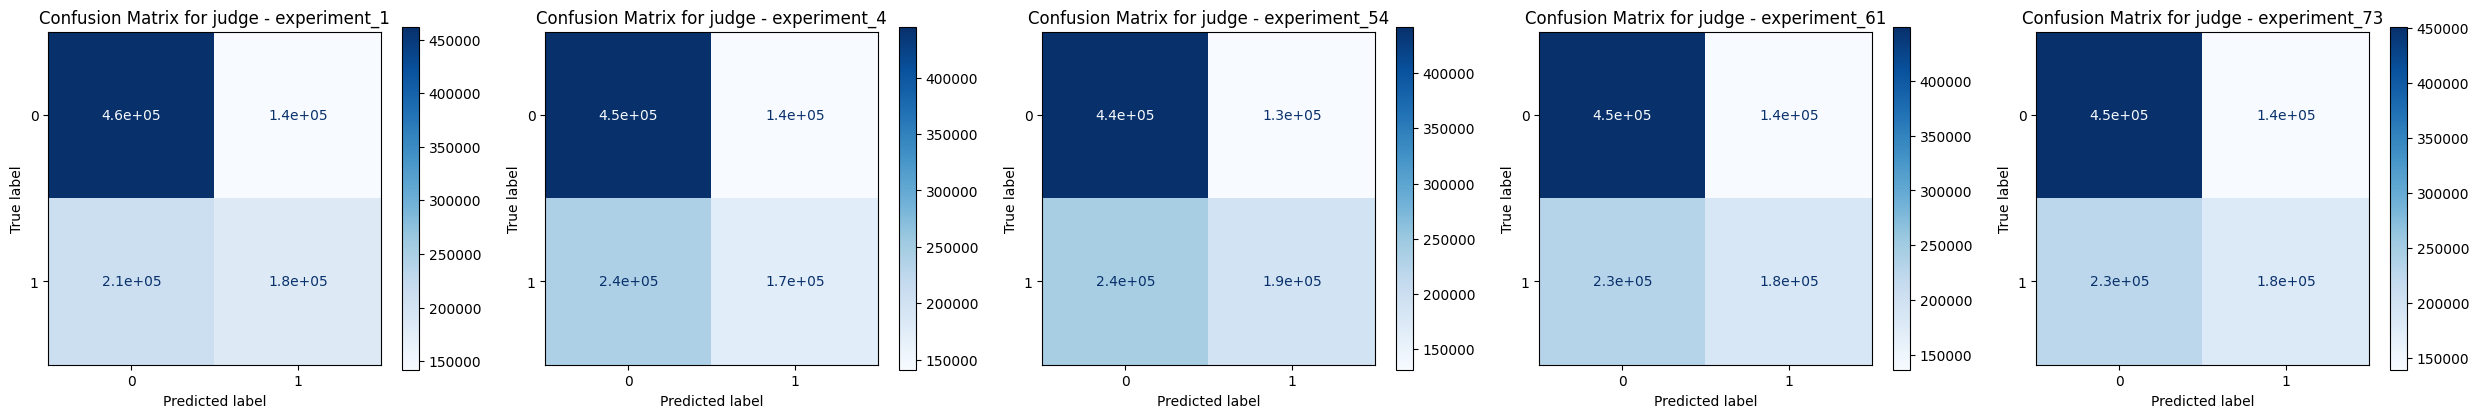

In [24]:
plot_confusion_matrix_by_experiment(confusion_df, "judge")

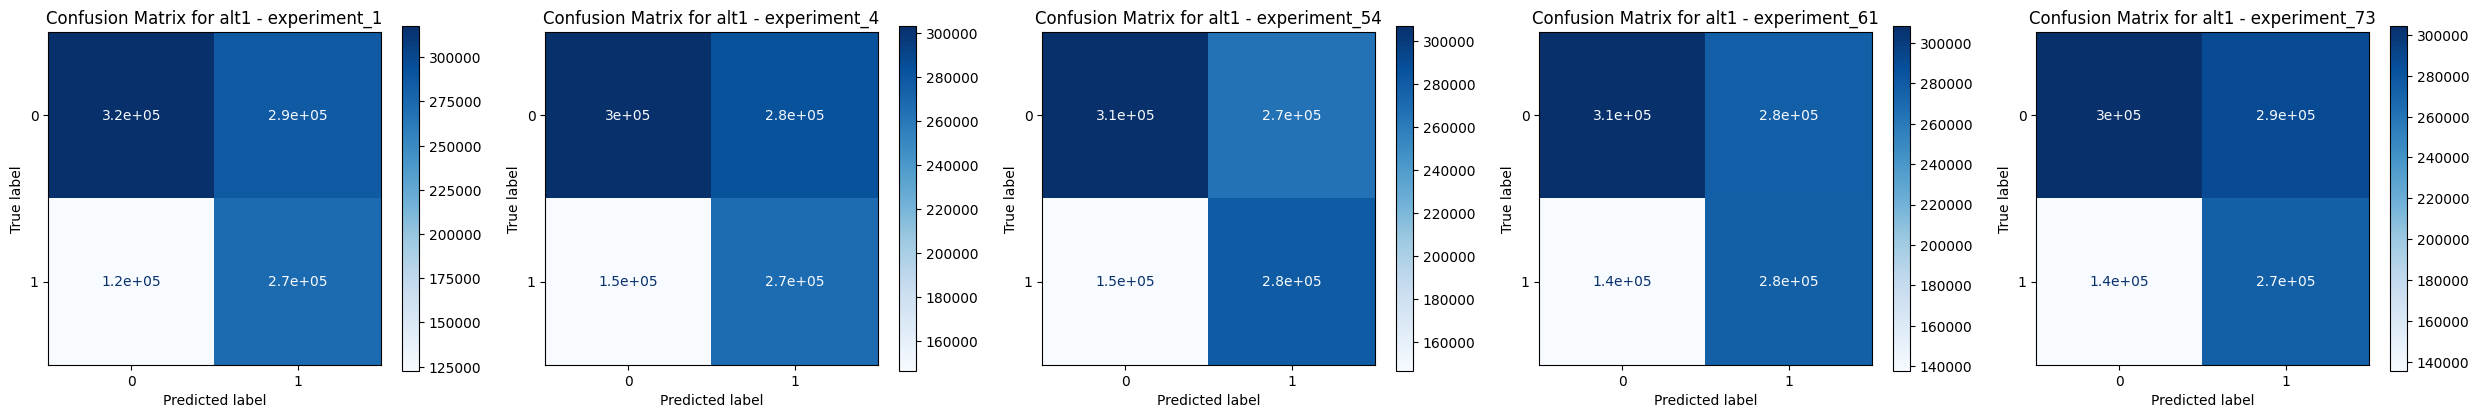

In [25]:
plot_confusion_matrix_by_experiment(confusion_df, "alt1")

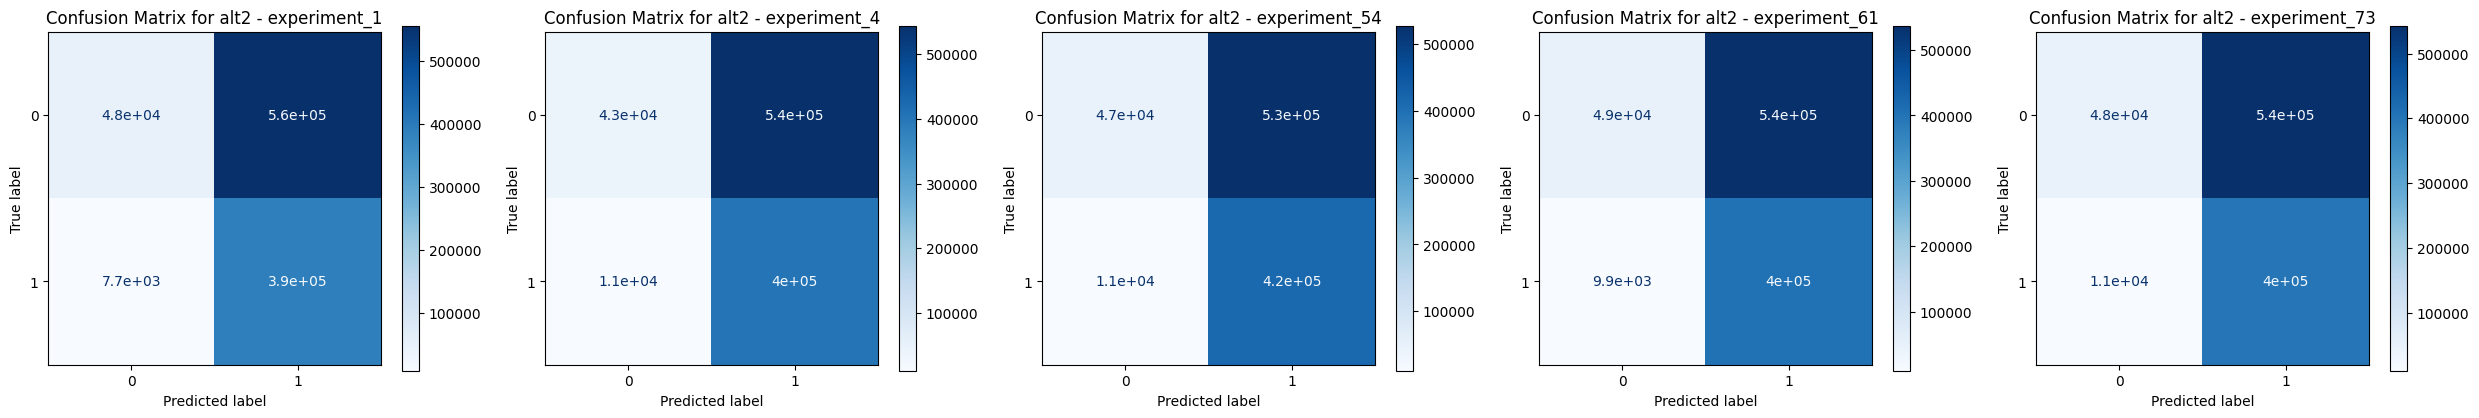

In [26]:
plot_confusion_matrix_by_experiment(confusion_df, "alt2")

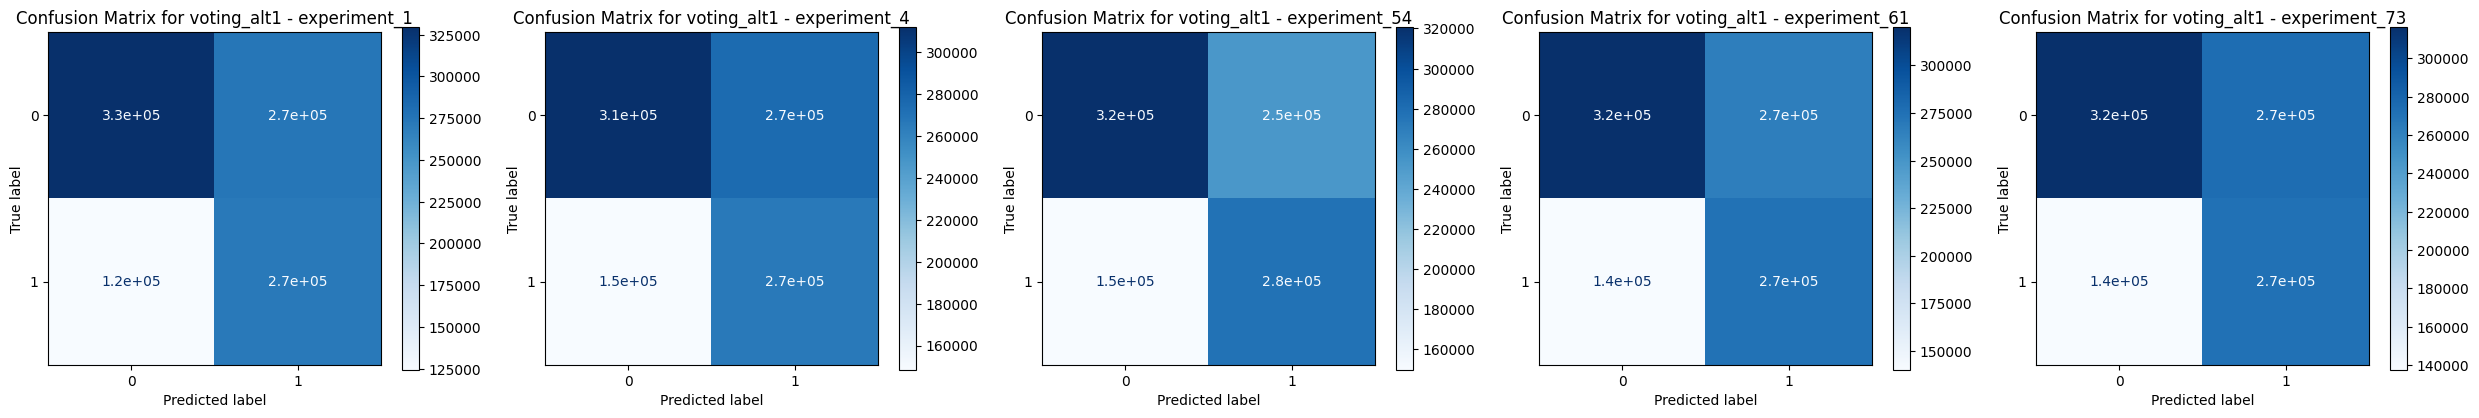

In [27]:
plot_confusion_matrix_by_experiment(confusion_df, "voting_alt1")

In [31]:
confusion_df.write_csv("confusion_df.csv")